# Plots of 3C and 3D
For latest R1-0528 in detail analysis

In [1]:
import os
import json
import pandas as pd
import numpy as np
import math
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from plot_v2 import *

In [2]:
def load_ndjson(file):
    output = []
    with open(file, "r") as f:  
        for line in f:
            line = line.strip()  
            if line:  
                try:
                    single_cell = json.loads(line)
                    output.append(single_cell)
                except json.JSONDecodeError as e:
                    print(f"Error decoding JSON from line: {e}")
    return output
def load_json(file):
    with open(file, "r") as f:
        try:
            data = json.load(f)
            return data
        except json.JSONDecodeError as e:
            print(f"Error decoding JSON from file: {e}")
            return None
        
def create_np_array_from_tissue_df(tissue_df):
    """
    Converts the output of the provided loop into a 4 x n NumPy array.

    Args:
        tissue_df: A dictionary where keys are tissue names (t) and values
                   are lists of dictionaries, each containing a 'match_scTab' key.

    Returns:
        A NumPy array of shape (m, n), where m is number of dfs,` n is the number of tissues
    """

    num_tissues = len(tissue_df)
    num_dfs = len(tissue_df[list(tissue_df.keys())[0]])
    result_array = np.zeros((num_dfs, num_tissues))

    for i, (t, df) in enumerate(tissue_df.items()):
        for j in range(num_dfs):
            result_array[j, i] = np.mean(df[j]['match_scTab'])

    return result_array


def macro_f1_from_df(df: pd.DataFrame) -> float:
    """
    从 Pandas DataFrame 计算 macro_f1 分数。

    DataFrame 必须包含以下列:
    - 'ground_truth_label': 实例的真实标签。
    - 'predicted_label': 模型预测的标签。
    - 'match_scTab': 一个布尔列 (True/False)，指示预测是否被认为是正确的
                     (例如，根据 scTab 规则，精确匹配或预测是真实标签的子节点等)。

    参数:
        df (pd.DataFrame): 输入的 DataFrame。

    返回:
        float: 计算得到的 macro_f1 分数。
    """
    required_cols = ['ground_truth_label', 'predicted_label', 'match_scTab']
    for col in required_cols:
        if col not in df.columns:
            raise ValueError(f"DataFrame 必须包含列: '{col}'")

    # 复制 DataFrame 以避免修改原始数据
    df_eval = df.copy()
    if df_eval.shape[0]==0: return np.float64('nan')

    # 确保 'match_scTab' 列是布尔类型，并将NA视作False (不匹配)
    if df_eval['match_scTab'].isnull().any():
        df_eval['match_scTab'] = df_eval['match_scTab'].fillna(False)
    df_eval['match_scTab'] = df_eval['match_scTab'].astype(bool)

    # 获取所有唯一的真实标签，用于计算每个类别的指标
    # 过滤掉空字符串或纯空格的标签，以及NaN值
    gt_labels_present = df_eval['ground_truth_label'].dropna().unique()
    gt_labels_present = [str(label) for label in gt_labels_present if str(label).strip() != ""]
    gt_labels_present = sorted(list(set(gt_labels_present))) # Ensure uniqueness and consistent order

    if not gt_labels_present:
        return 0.0

    f1_scores = []

    for label_class in gt_labels_present:
        # True Positives (TP): 真实标签是当前类别，并且预测是正确的
        tp = ((df_eval['ground_truth_label'] == label_class) & (df_eval['match_scTab'] == True)).sum()
        
        # False Negatives (FN): 真实标签是当前类别，但预测是错误的
        fn = ((df_eval['ground_truth_label'] == label_class) & (df_eval['match_scTab'] == False)).sum()
        
        # False Positives (FP): 预测标签是当前类别，但预测是错误的
        fp = ((df_eval['predicted_label'] == label_class) & (df_eval['match_scTab'] == False)).sum()

        precision = 0.0
        if (tp + fp) > 0:
            precision = tp / (tp + fp)
        
        recall = 0.0
        if (tp + fn) > 0:
            recall = tp / (tp + fn)
        
        f1 = 0.0
        if (precision + recall) > 0:
            f1 = 2 * (precision * recall) / (precision + recall)
        
        f1_scores.append(f1)

    if not f1_scores:
        macro_f1 = 0.0
    else:
        macro_f1 = sum(f1_scores) / len(f1_scores)
        
    return macro_f1
def f1_np_array_from_tissue_df(tissue_df):
    """
    """

    num_tissues = len(tissue_df)
    num_dfs = len(tissue_df[list(tissue_df.keys())[0]])
    result_array = np.zeros((num_dfs, num_tissues))

    for i, (t, df) in enumerate(tissue_df.items()):
        for j in range(num_dfs):
            f = macro_f1_from_df(df[j])
            result_array[j, i] = f


    return result_array


In [3]:
def split_by_matching(ground_truth_children_dict, model_labels):
    '''
    Find ground truth cells that are in the model labels and not in the model labels
    '''
    matched_celltypes = []
    unmatched_celltypes = []
    for cell, children in ground_truth_children_dict.items():
        if set(children).intersection(model_labels):
            matched_celltypes.append(cell)
        else: unmatched_celltypes.append(cell)
    return {'matched':matched_celltypes, 'unmatched':unmatched_celltypes}

def split_dataset(df_list, index_dict, df_col):
    ''' 
    split df_list to separate lists according to df_col and index_dict
    '''
    df_dict = {}
    for k,v in index_dict.items():
        df_dict[k] = [df[df[df_col].isin(v)] for df in df_list]
    return df_dict

def add_in_label(
    df_list,
    str_list,
    name_col: str = "name",
    new_col: str = "in_label",
    in_place: bool = True,
):
    """
    Modify the df list, add a col to indicate if ground true is in/off label
    Add a boolean column `new_col` to every DataFrame in `df_list`,
    indicating whether the value in `name_col` is contained in `str_list`.

    Parameters
    ----------
    df_list : list[pd.DataFrame]
        A list of DataFrames that all contain the column `name_col`.
    str_list : Iterable[str]
        Collection of strings used for membership testing.
    name_col : str, default "name"
        Column to be checked against `str_list`.
    new_col : str, default "in_label"
        Name of the new column to be created.
    in_place : bool, default True
        • True  → modify each DataFrame in place and return the *same* list.  
        • False → work on copies and return a *new* list.

    Returns
    -------
    list[pd.DataFrame]
        The list of modified DataFrames (original objects if `in_place=True`).

    Notes
    -----
    * Missing values (`NaN`, `pd.NA`, `None`) are preserved as missing.
    * Converting `str_list` to a `set` speeds up membership checks.
    """
    string_set = set(str_list)

    def _process_df(df: pd.DataFrame) -> pd.DataFrame:
        # Vectorised test for membership
        hits = df[name_col].isin(string_set)

        # Preserve missing values
        new_series = np.where(df[name_col].isna(), pd.NA, hits)

        df[new_col] = new_series
        return df

    if in_place:
        for d in df_list:
            _process_df(d)
        return df_list
    else:
        return [_process_df(d.copy(deep=True)) for d in df_list]

In [4]:
# load cell type label information for sctab, scgpt and ground truth
# get mapped results for scTab labels
sctab_results = load_ndjson('/cristealab/xiwang/DSR1_Preprint/Outputs/Celltype_alignment/scTab_labels/step2_matched.ndjson')
sctab_celltypes_mapped = [result['predicted_label_clean'] for result in sctab_results]
# get mapped results for scgpt labels
scgpt_results = load_ndjson('/cristealab/xiwang/DSR1_Preprint/Outputs/Celltype_alignment/scGPT_labels/step2_matched.ndjson')
scgpt_celltypes_mapped = [result['predicted_label_clean'] for result in scgpt_results]
# get each ground truth celltype's all children
ground_truth_children = load_json('/cristealab/xiwang/DSR1_Preprint/Outputs/Celltype_alignment/groundtruth_labels/results.json')
ground_truth_children_dict = {
    cell["ground_truth_label"]:cell["ground_truth_children"] for cell in ground_truth_children['cells']
} 
for i in range(len(ground_truth_children['cells'])):
    ground_truth_children_dict[ground_truth_children['cells'][i]["ground_truth_label"]]=ground_truth_children['cells'][i]["ground_truth_children"]


# split ground truth cell types label by in/off sctab
sctab_split = split_by_matching(ground_truth_children_dict, sctab_celltypes_mapped)
# by scgpt
scgpt_split = split_by_matching(ground_truth_children_dict, scgpt_celltypes_mapped)

In [5]:
# load results for 8d 
file_paths_8d = [
    '/cristealab/xiwang/DSR1_Preprint/Outputs/cellxgene_cutoff_8datasets_10k_v2/responses/scTab/results.csv',
    '/cristealab/xiwang/DSR1_Preprint/Outputs/cellxgene_cutoff_8datasets_10k_v2/responses/scGPT/results.csv',
    '/cristealab/xiwang/DSR1_Preprint/Outputs/cellxgene_cutoff_8datasets_10k_v2/responses/short_prompt_r1_0528/100genes_scGPTClassifier/results.csv',
    '/cristealab/xiwang/DSR1_Preprint/Outputs/cellxgene_cutoff_8datasets_10k_v2/responses/short_prompt_r1_0528/100genes_scTabClassifier/results.csv',
    '/cristealab/xiwang/DSR1_Preprint/Outputs/cellxgene_cutoff_8datasets_10k_v2/responses/short_prompt_r1_0528/100genes/results.csv'
]
# cellxgene 8d data
sctab_8d, scgpt_8d, r1_scgpt_cls_8d, r1_sctab_cls_8d, r1_8d = (pd.read_csv(file) for file in file_paths_8d)

In [6]:
# models whose performance are evaluated and plotted
models = ['scTab', 'R1 (scGPT Classifier)', 'R1 (scTab Classifier)', 'scGPT', 'R1']

In [7]:
# plots for datasets of balanced tissues
# result dfs by order
prediction_df_8d = [sctab_8d, r1_scgpt_cls_8d, r1_sctab_cls_8d, scgpt_8d, r1_8d]
# add tissue col for tissue split
cells_8d = load_ndjson('/cristealab/xiwang/DSR1_Preprint/Outputs/cellxgene_cutoff_8datasets_10k_v2/prompts/prompts_100genes.ndjson')
id_to_tissue = {str(cell['soma_joinid']):cell['tissue'] for cell in cells_8d}
for df in prediction_df_8d:
    df['tissue'] = ''
    df.loc[df['cell'].isin(id_to_tissue), 'tissue'] = df['cell'].map(id_to_tissue)

In [8]:
# split ground truth cell types by matching
# by sctab
prediction_df_8d_by_sctab = split_dataset(prediction_df_8d, sctab_split, 'ground_truth_label')
# by scgpt
prediction_df_8d_by_scgpt = split_dataset(prediction_df_8d, scgpt_split, 'ground_truth_label')

In [10]:
prediction_df_8d[0]

,cell,ground_truth_label,predicted_label,verdict,match_scTab,tissue
0,61989204,retinal bipolar neuron,pericyte,NO_DIRECT_CHILD_RELATION,False,peripheral region of retina
1,61602271,invaginating midget bipolar cell,pericyte,NO_DIRECT_CHILD_RELATION,False,peripheral region of retina
2,61628059,retinal rod cell,retinal cone cell,NO_DIRECT_CHILD_RELATION,False,peripheral region of retina
3,61927017,flat midget bipolar cell,pericyte,NO_DIRECT_CHILD_RELATION,False,peripheral region of retina
4,62239331,flat midget bipolar cell,L2 intratelencephalic projecting glutamatergic...,NO_DIRECT_CHILD_RELATION,False,peripheral region of retina
...,...,...,...,...,...,...
10001,EVALUATION_METRICS,NUM_TRUE,2017,NaN,NaN,
10002,EVALUATION_METRICS,ACCURACY,0.2017,NaN,NaN,
10003,EVALUATION_METRICS,MACRO_F1,0.1597,NaN,NaN,
10004,EVALUATION_METRICS,WEIGHTED_F1,0.1874,NaN,NaN,


In [9]:
overall_acc = [float(df.iloc[-5,2])/(10000-382) for df in prediction_df_8d] # based on non-missing cells
sctab_acc = create_np_array_from_tissue_df(prediction_df_8d_by_sctab)
scgpt_acc = create_np_array_from_tissue_df(prediction_df_8d_by_scgpt)

In [20]:
np.column_stack((sctab_acc, scgpt_acc)).shape

(5, 4)

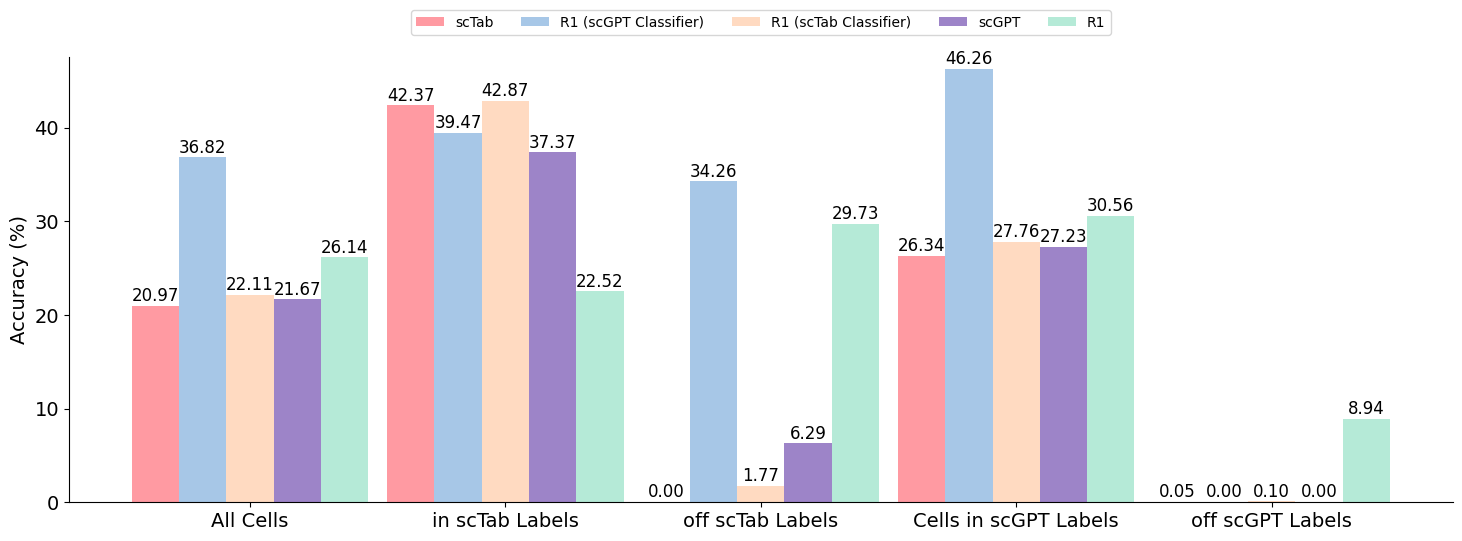

In [17]:
overall_acc = [float(df.iloc[-5,2])/(10000-382) for df in prediction_df_8d] # based on non-missing cells
sctab_acc = create_np_array_from_tissue_df(prediction_df_8d_by_sctab)
scgpt_acc = create_np_array_from_tissue_df(prediction_df_8d_by_scgpt)
plotter = MetricPlotter(bar_width = 0.5, annotation_digits=2, 
                        y_lim_lower = 0, 
                        # y_lim_upper=100
                        )
plotter.display_axes_borders = 'xy'
plotter.group_gap = 0.2
plotter.text_margin = 0.001
plotter.ncol_legend = 5
plotter.colors = ['#FF9AA2','#A7C7E7','#FFDAC1','#9D84C8','#B5EAD7',]
plotter.bar_fontsize = 12
plotter.x_label_fontsize = 14
plotter.y_label_fontsize=14
plotter.x_tick_fontsize=14
plotter.y_tick_fontsize=14
groups = ['All Cells', 'in scTab Labels','off scTab Labels','Cells in scGPT Labels','off scGPT Labels']
plotter.group_barplot(groups,models,metrics = np.column_stack((overall_acc, sctab_acc, scgpt_acc)), 
             x_label="", y_label="Accuracy", 
             # title="LLMs' Performance for Clusters"
             )

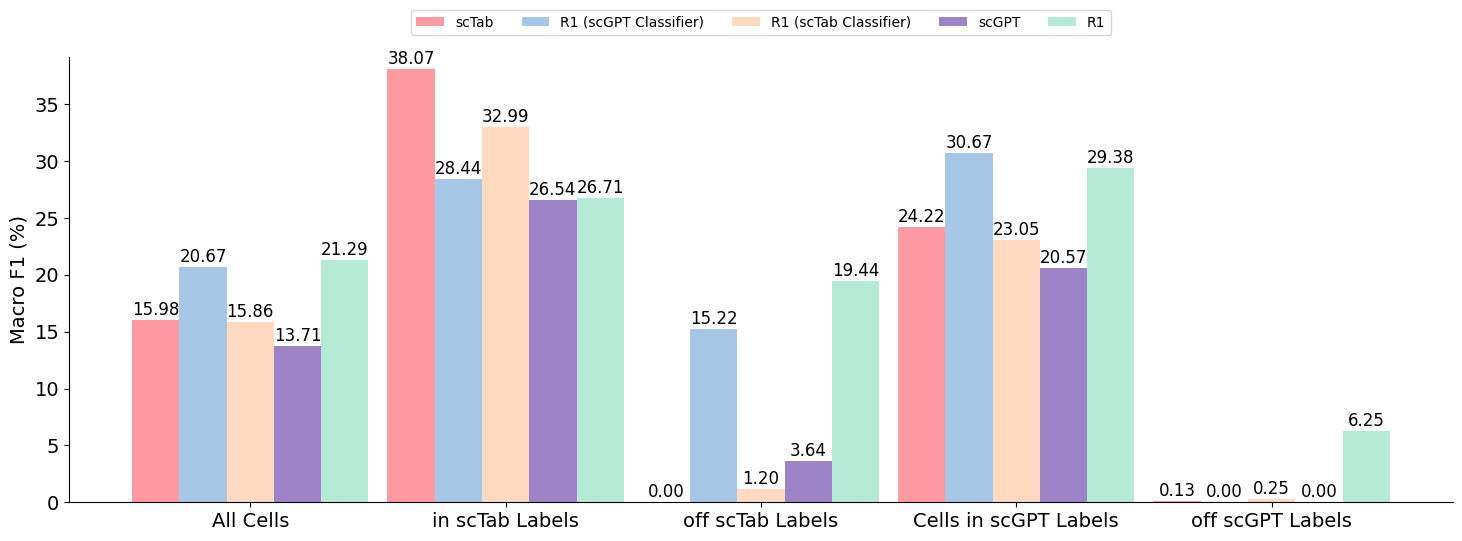

In [10]:
# remove missing of 8d for f1
prediction_df_8d = [df[:10000] for df in prediction_df_8d]; prediction_df_8d = [df.dropna(subset=['ground_truth_label']) for df in prediction_df_8d]
overall_f1 = [macro_f1_from_df(df) for df in prediction_df_8d]
sctab_f1 = f1_np_array_from_tissue_df(prediction_df_8d_by_sctab)
scgpt_f1 = f1_np_array_from_tissue_df(prediction_df_8d_by_scgpt)
plotter = MetricPlotter(bar_width = 0.5, annotation_digits=2, 
                        y_lim_lower = 0, 
                        # y_lim_upper=100
                        )
plotter.display_axes_borders = 'xy'
plotter.group_gap = 0.2
plotter.text_margin = 0.001
plotter.ncol_legend = 5
plotter.colors = ['#FF9AA2','#A7C7E7','#FFDAC1','#9D84C8','#B5EAD7',]
plotter.bar_fontsize = 12
plotter.x_label_fontsize = 14
plotter.y_label_fontsize=14
plotter.x_tick_fontsize=14
plotter.y_tick_fontsize=14
groups = ['All Cells', 'in scTab Labels','off scTab Labels','Cells in scGPT Labels','off scGPT Labels']
plotter.group_barplot(groups,models,metrics = np.column_stack((overall_f1, sctab_f1, scgpt_f1)), 
             x_label="", y_label="Macro F1", 
             # title="LLMs' Performance for Clusters"
             )

In [11]:
# split by tissues in all cells
# tissues = set([cell['tissue'] for cell in cells_8d])
tissues= ['blood', 'pancreas', 'breast', 'lung', 'cerebellum', 'trachea', 'kidney', 'peripheral region of retina']
tissue_index = {t:[t] for t in tissues}
prediction_df_8d_by_tissue = split_dataset(prediction_df_8d, tissue_index, 'tissue')
tissue_acc = create_np_array_from_tissue_df(prediction_df_8d_by_tissue)
tissue_f1 = f1_np_array_from_tissue_df(prediction_df_8d_by_tissue)

# split by tissues in scTab labels
prediction_df_8d_in_sctab_by_tissue = split_dataset(prediction_df_8d_by_sctab['matched'], tissue_index, 'tissue')
# split by tissues off scTab labels
prediction_df_8d_off_sctab_by_tissue = split_dataset(prediction_df_8d_by_sctab['unmatched'], tissue_index, 'tissue')


In [20]:
# number of cells for each tissue
for tissue, dfs in prediction_df_8d_by_tissue.items():
    print(tissue, dfs[0].shape[0])

blood 1250
pancreas 1250
breast 1250
lung 868
cerebellum 1250
trachea 1250
kidney 1250
peripheral region of retina 1250


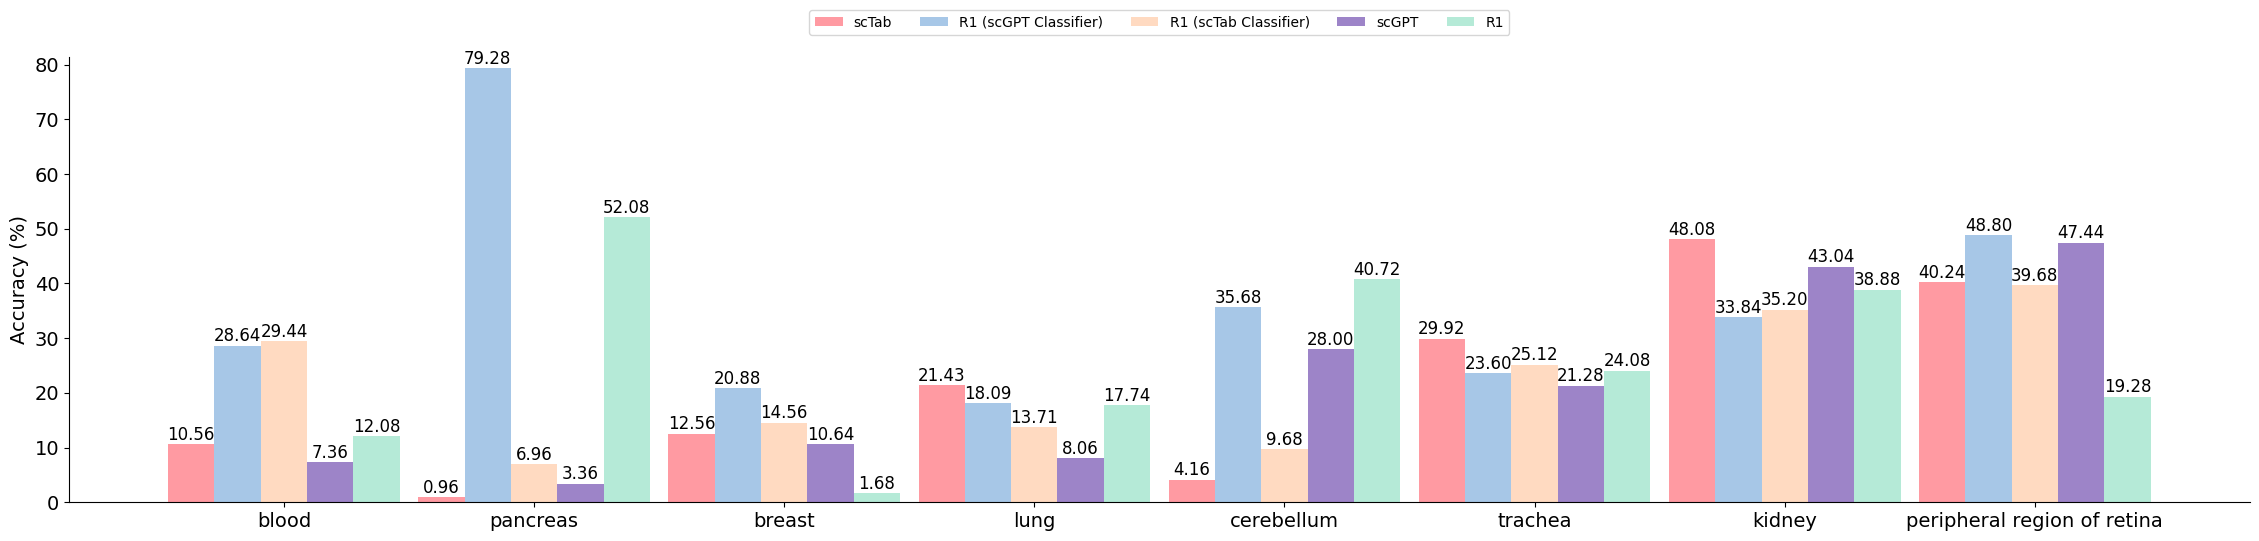

In [ ]:
plotter.group_barplot(tissue_index.keys(),models,metrics = tissue_acc, 
             x_label="", y_label="Accuracy"
             )

In [22]:
def plot_heatmap(
    data,
    row_names=None,
    col_names=None,
    title: str = "Heatmap",
    xlabel: str = "Columns",
    ylabel: str = "Rows",
    cmap = "viridis",
    annot = True,
    fmt: str = ".2f",
    linewidths: float = 0.5,
    linecolor: str = "lightgray",
    cbar: bool = False,
    figsize = (10, 8),
    xtick_rotation = 45,
    ax=None,
    vmin = None,
    vmax = None,
    nan_color: str = "grey",
    annot_fontsize = None,
    xtick_fontsize = 16,
    ytick_fontsize = 16,
    **kwargs,
):
    """
    Draw a heatmap for an *m × n* data matrix with percentage annotations.
    
    Parameters
    ----------
    data : array-like | pandas.DataFrame
        Matrix to plot (shape m × n).
    row_names, col_names : list-like | None
        Row/column labels if *data* is not a DataFrame.
    title, xlabel, ylabel : str
        Figure and axis titles.
    cmap : str | matplotlib.colors.Colormap
        Colormap for the heatmap.
    annot : bool | array-like
        If ``True``, display each cell’s numeric value (converted to %).
        If array-like, use it directly.
    fmt : str
        ``str.format`` specification for annotations (after ×100).
    linewidths, linecolor : float | str
        Grid line width / colour.
    cbar : bool
        Whether to draw a colour bar.
    figsize : (width, height)
        Figure size in inches (ignored if *ax* is supplied).
    xtick_rotation : int | float
        Rotation applied to x-tick labels.
    ax : matplotlib.axes.Axes | None
        Existing axes to draw on; create new ones if ``None``.
    vmin, vmax : float | None
        Fixed colour scale limits; ``None`` lets seaborn pick them.
    nan_color : str
        Colour for ``NaN`` cells.
    annot_fontsize, xtick_fontsize, ytick_fontsize : int | float | None
        Font sizes for annotations and tick labels.
    **kwargs
        Extra keyword arguments passed straight to ``seaborn.heatmap``.

    Returns
    -------
    matplotlib.axes.Axes
        The axes containing the heatmap.
    """
    # --------------------------------------------------------------------- #
    # 1. Convert *data* to DataFrame so row/col labels are easy to manage   #
    # --------------------------------------------------------------------- #
    if isinstance(data, pd.DataFrame):
        plot_data = data.copy()
        _row_names = data.index.tolist() if row_names is None else row_names
        _col_names = data.columns.tolist() if col_names is None else col_names
    else:
        plot_data = pd.DataFrame(data, index=row_names, columns=col_names)
        _row_names = plot_data.index.tolist()
        _col_names = plot_data.columns.tolist()

    # --------------------------------------------------------------------- #
    # 2. Create (or re-use) axes                                            #
    # --------------------------------------------------------------------- #
    if ax is None:
        fig, current_ax = plt.subplots(figsize=figsize)
    else:
        current_ax = ax
        fig = current_ax.figure

    # Copy colormap so we can safely mutate the “bad” colour for NaNs
    current_cmap = plt.cm.get_cmap(cmap)
    custom_cmap = current_cmap.copy()
    custom_cmap.set_bad(color=nan_color)

    # --------------------------------------------------------------------- #
    # 3. Prepare annotation keyword args                                    #
    # --------------------------------------------------------------------- #
    current_annot_kws = kwargs.pop("annot_kws", {}).copy()
    if annot_fontsize is not None:
        current_annot_kws["fontsize"] = annot_fontsize

    # --------------------------------------------------------------------- #
    # 4. Automatically turn values into percentages if annot is True        #
    # --------------------------------------------------------------------- #
    if isinstance(annot, bool):
        annot_to_use = plot_data * 100 if annot else False
    else:  # user supplied custom annotations → do not alter
        annot_to_use = annot

    # --------------------------------------------------------------------- #
    # 5. Draw the heatmap                                                   #
    # --------------------------------------------------------------------- #
    sns.heatmap(
        plot_data,
        annot=annot_to_use,
        fmt=fmt,
        cmap=custom_cmap,
        linewidths=linewidths,
        linecolor=linecolor,
        cbar=cbar,
        ax=current_ax,
        xticklabels=True,
        yticklabels=True,
        vmin=vmin,
        vmax=vmax,
        annot_kws=current_annot_kws if current_annot_kws else None,
        **kwargs,
    )

    # --------------------------------------------------------------------- #
    # 6. Axis-level aesthetics                                              #
    # --------------------------------------------------------------------- #
    current_ax.set_title(title, fontsize=14, fontweight="bold")
    current_ax.set_xlabel(xlabel, fontsize=20)
    current_ax.set_ylabel(ylabel, fontsize=20)

    current_ax.set_xticks(np.arange(len(_col_names)) + 0.5)
    current_ax.set_yticks(np.arange(len(_row_names)) + 0.5)
    current_ax.set_xticklabels(_col_names)
    current_ax.set_yticklabels(_row_names)

    # Tick-label font sizes
    if xtick_fontsize is not None:
        plt.setp(current_ax.get_xticklabels(), fontsize=xtick_fontsize)
    if ytick_fontsize is not None:
        plt.setp(current_ax.get_yticklabels(), fontsize=ytick_fontsize)

    # Tick-label rotation
    if xtick_rotation not in (None, 0):
        plt.setp(
            current_ax.get_xticklabels(),
            rotation=xtick_rotation,
            ha="right",
            rotation_mode="anchor",
        )
    elif xtick_rotation == 0:
        plt.setp(current_ax.get_xticklabels(), rotation=0, ha="center")

    plt.setp(current_ax.get_yticklabels(), rotation=0)

    # Tight layout for new figures (won’t interfere if *ax* was provided)
    if ax is None:
        try:
            fig.tight_layout()
        except (ValueError, RuntimeError):
            # Occasional failure with very small figures
            print("Warning: tight_layout failed; elements may overlap.")

    return current_ax


/tmp/ipykernel_2253235/505786259.py:89: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  current_cmap = plt.cm.get_cmap(cmap)


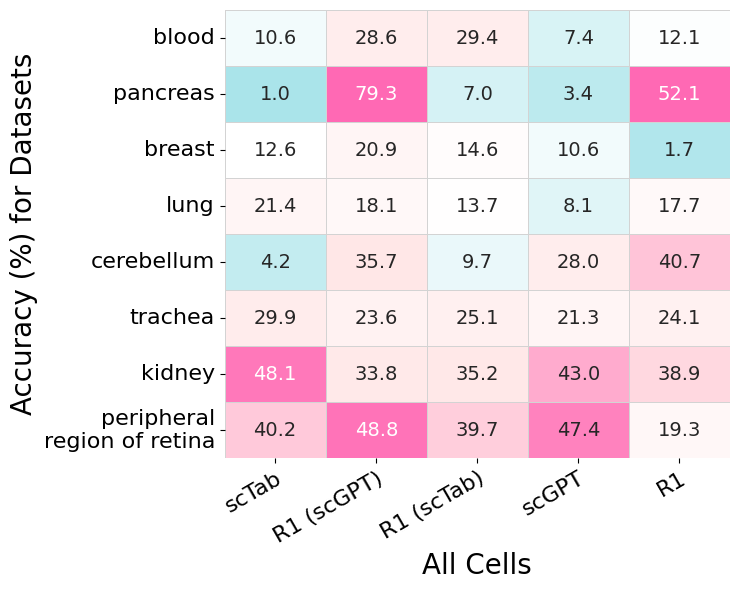

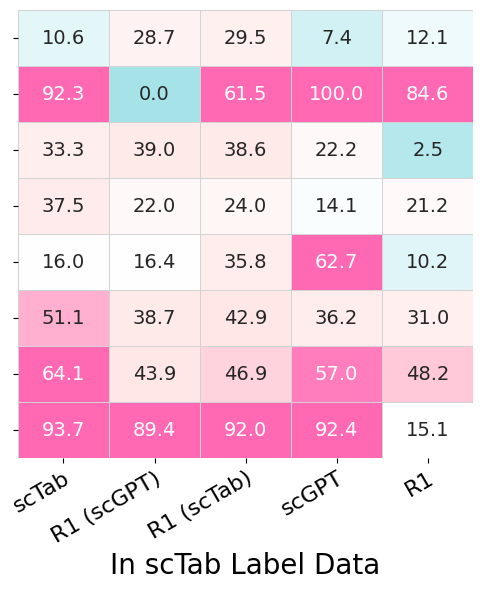

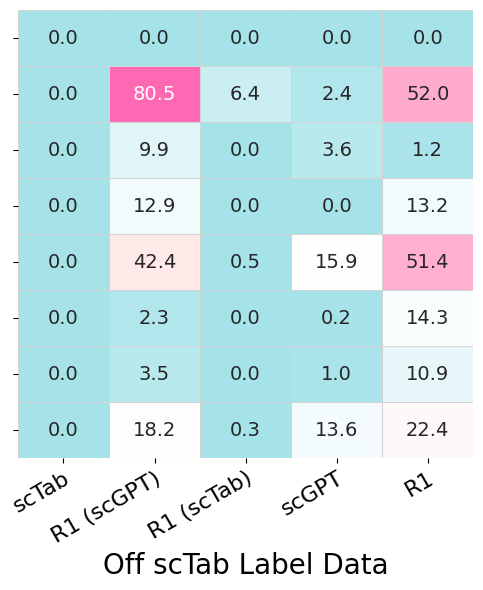

In [23]:
from matplotlib.colors import LinearSegmentedColormap # Import this
# Use hex codes or color names recognized by matplotlib
colors = ["#A6E3E9","#FFFFFF",'#FFF0F0','#FFE6E6',"#FF69B4"]
n_bins = 100 # Number of discrete color steps
cmap_name = "YlOrPi_custom"
my_cmap = LinearSegmentedColormap.from_list(cmap_name, colors, N=n_bins)

tissue_names = [tissue for tissue in tissue_index.keys()]
for i in range(len(tissue_names)): 
    if tissue_names[i] == 'peripheral region of retina':
        tissue_names[i] = 'peripheral\nregion of retina'
models = ['scTab', 'R1 (scGPT)', 'R1 (scTab)', 'scGPT', 'R1']

ax1 = plot_heatmap(
    tissue_acc.T,
    row_names=tissue_names,
    col_names=models,
    title="",
    xlabel="All Cells",
    ylabel="Accuracy (%) for Datasets",
    cmap=my_cmap,      # Diverging colormap
    fmt=".1f",            # One decimal place
    figsize=(7.5, 6),       # Custom size
    xtick_rotation=30,
    vmin=0,
    vmax=0.5, annot_fontsize = 14
)
plt.show()

ax1 = plot_heatmap(
    create_np_array_from_tissue_df(prediction_df_8d_in_sctab_by_tissue).T,
    row_names=['']*8,
    col_names=models,
    title="",
    xlabel="In scTab Label Data",
    ylabel="",
    cmap=my_cmap,      # Diverging colormap
    fmt=".1f",            # One decimal place
    figsize=(5, 6),       # Custom size
    xtick_rotation=30,
    vmin=0,
    vmax=0.6, annot_fontsize = 14
)
plt.show()

ax1 = plot_heatmap(
    create_np_array_from_tissue_df(prediction_df_8d_off_sctab_by_tissue).T,
    row_names=['']*8,
    col_names=models,
    title="",
    xlabel="Off scTab Label Data",
    ylabel="",
    cmap=my_cmap,      # Diverging colormap
    fmt=".1f",            # One decimal place
    figsize=(5, 6),       # Custom size
    xtick_rotation=30,
    vmin=0,
    vmax=0.6, annot_fontsize = 14
)
plt.show()

/tmp/ipykernel_2253235/505786259.py:89: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  current_cmap = plt.cm.get_cmap(cmap)


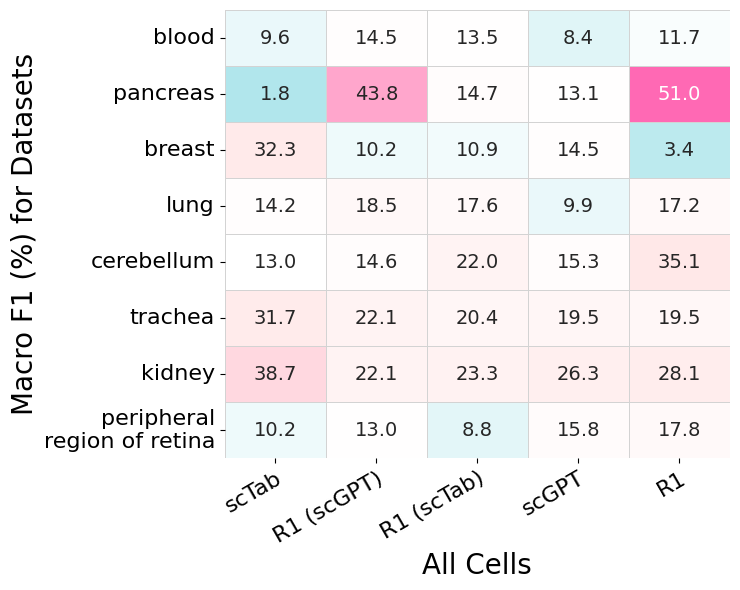

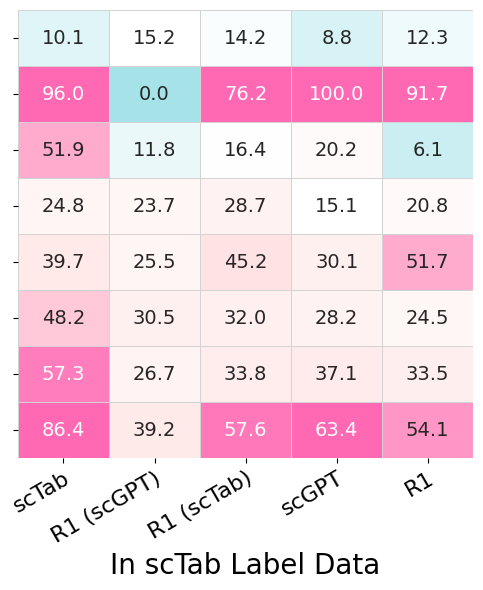

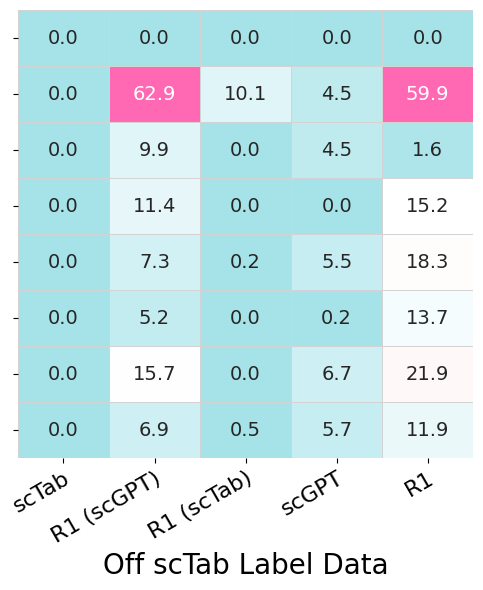

In [24]:
ax1 = plot_heatmap(
    tissue_f1.T,
    row_names=tissue_names,
    col_names=models,
    title="",
    xlabel="All Cells",
    ylabel="Macro F1 (%) for Datasets",
    cmap=my_cmap,      # Diverging colormap
    fmt=".1f",            # One decimal place
    figsize=(7.5, 6),       # Custom size
    xtick_rotation=30,
    vmin=0,
    vmax=0.5, annot_fontsize = 14
)
plt.show()

ax1 = plot_heatmap(
    f1_np_array_from_tissue_df(prediction_df_8d_in_sctab_by_tissue).T,
    row_names=['']*8,
    col_names=models,
    title="",
    xlabel="In scTab Label Data",
    ylabel="",
    cmap=my_cmap,      # Diverging colormap
    fmt=".1f",            # One decimal place
    figsize=(5, 6),       # Custom size
    xtick_rotation=30,
    vmin=0,
    vmax=0.6, annot_fontsize = 14
)
plt.show()

ax1 = plot_heatmap(
    f1_np_array_from_tissue_df(prediction_df_8d_off_sctab_by_tissue).T,
    row_names=['']*8,
    col_names=models,
    title="",
    xlabel="Off scTab Label Data",
    ylabel="",
    cmap=my_cmap,      # Diverging colormap
    fmt=".1f",            # One decimal place
    figsize=(5, 6),       # Custom size
    xtick_rotation=30,
    vmin=0,
    vmax=0.6, annot_fontsize = 14
)
plt.show()

# Off label balanced tissue OOD

In [12]:
# add in_scTab_label col
add_in_label(prediction_df_8d, str_list=sctab_split['matched'], name_col='ground_truth_label', new_col='in_scTab_label')
# remove metrics rows to keep cell rows only
df_8d = [df[:10000] for df in prediction_df_8d]

In [13]:
from functools import reduce
from openpyxl.utils import get_column_letter
from openpyxl import load_workbook
from typing import List

def merge_and_split_to_xlsx(
    df_list: List[pd.DataFrame],
    df_names: List[str],
    output_path: str,
    *,
    key_col: str = "cell",
    shared_cols: List[str] = ("in_scTab_label", "tissue", "ground_truth_label"),
    engine: str = "openpyxl",
) -> None:
    """
    Merge a list of DataFrames on *key_col*, keep exactly one copy of the columns
    in *shared_cols*, prefix every other column with the corresponding entry in
    *df_names*, and write an Excel workbook that contains one worksheet per
    tissue type.

    Parameters
    ----------
    df_list : list[pandas.DataFrame]
        Input DataFrames (identical schema before processing).
    df_names : list[str]
        Prefixes, in the same order as *df_list* (e.g. 
        ['scTab', 'R1_scGPT', 'R1_scTab', 'scGPT', 'R1']).
    output_path : str
        Full path, including “.xlsx”, where the workbook is written.
    key_col : str, default "cell"
        Column on which rows are aligned.
    shared_cols : list[str], default ("in_scTab_label", "tissue", "ground_truth_label")
        Columns that are identical across every DataFrame and should appear only
        once in the merged result (kept in the order provided).
    engine : str, default "openpyxl"
        Excel writer engine.

    Notes
    -----
    * Each DataFrame first renames the column ``match_scTab`` to ``match`` so
      the subsequent processing steps work on a unified schema.
    * Column widths in the final workbook are set so that every column is at
      least as wide as its header text (monospaced assumption).
    """
    if len(df_list) != len(df_names):
        raise ValueError("`df_list` and `df_names` must have the same length")

    processed: List[pd.DataFrame] = []

    # ------------------------------------------------------------------ #
    # 1‒ Prepare individual DataFrames                                   #
    # ------------------------------------------------------------------ #
    for idx, (prefix, df) in enumerate(zip(df_names, df_list)):
        df = df.copy()

        # Unify the column name for the match indicator.
        df.rename(columns={"match_scTab": "match"}, inplace=True, errors="ignore")

        # Add a prefix to every column that is *not* shared and not the key.
        cols_to_prefix = [
            c for c in df.columns if c not in shared_cols and c != key_col
        ]
        df.rename(columns={c: f"{prefix}_{c}" for c in cols_to_prefix}, inplace=True)

        # After prefixes are attached, remove shared columns from every DataFrame
        # except the first one to avoid duplicates in the merge.
        if idx > 0:
            df = df.drop(columns=[c for c in shared_cols if c in df.columns])

        processed.append(df)

    # ------------------------------------------------------------------ #
    # 2‒ Merge all DataFrames on the key (outer join)                     #
    # ------------------------------------------------------------------ #
    merged = reduce(
        lambda left, right: left.merge(right, on=key_col, how="outer"),
        processed,
    )

    # Place columns in the order: key ▸ shared ▸ everything else.
    first_cols = [key_col, *shared_cols]
    other_cols = [c for c in merged.columns if c not in first_cols]
    merged = merged[first_cols + other_cols]

    # ------------------------------------------------------------------ #
    # 3‒ Write one worksheet per tissue                                  #
    # ------------------------------------------------------------------ #
    os.makedirs(os.path.dirname(output_path), exist_ok=True)

    with pd.ExcelWriter(output_path, engine=engine) as writer:
        for tissue, sub_df in merged.groupby("tissue", dropna=False):
            # Create a safe sheet name (≤31 chars, no : \ / ? * [ ]).
            sheet_name = (
                str(tissue) if pd.notna(tissue) else "NA"
            )[:31].translate({ord(c): "_" for c in r':\/?*[]'})
            sub_df.to_excel(writer, sheet_name=sheet_name, index=False)

    # ------------------------------------------------------------------ #
    # 4‒ Auto-size columns                                               #
    # ------------------------------------------------------------------ #
    wb = load_workbook(output_path)
    for ws in wb.worksheets:
        for idx, cell in enumerate(ws[1], start=1):  # first row = headers
            header_len = len(str(cell.value or ""))
            ws.column_dimensions[get_column_letter(idx)].width = max(header_len + 2, 10)

    wb.save(output_path)
    print(f"Workbook saved to {output_path}")

In [ ]:
# write the xlsx file for supplementary
prefixes = ['scTab', 'R1_scGPT', 'R1_scTab', 'scGPT', 'R1']
merge_and_split_to_xlsx(df_8d, prefixes, "/cristealab/xiwang/DSR1_Preprint/Outputs/cellxgene_cutoff_8datasets_10k_v2/responses/short_prompt_r1_0528/by_tissue_predictions.xlsx")

Workbook saved to /cristealab/xiwang/DSR1_Preprint/Outputs/cellxgene_cutoff_8datasets_10k_v2/responses/temp_short_prompt_r1_0528/by_tissue_predictions.xlsx


In [14]:
# load the by-tissue excel file
# Path to the workbook you wrote earlier
xlsx_path = "/cristealab/xiwang/DSR1_Preprint/Outputs/cellxgene_cutoff_8datasets_10k_v2/responses/short_prompt_r1_0528/by_tissue_predictions.xlsx"

# Read every sheet into a dict of DataFrames.
#   • keys   = sheet names
#   • values = corresponding DataFrames
sheets = pd.read_excel(
    xlsx_path,
    sheet_name=None,        # None ⇒ read all sheets
    engine="openpyxl",      # same engine used to write
)
# remove missing in lung
for name, df in sheets.items():
    if name == 'lung':
        sheets[name] = df.dropna(subset=['ground_truth_label'])


In [15]:
# Example: iterate or access
for name, df in sheets.items():
    print(f"{name}: {df.shape}")

blood: (1250, 19)
breast: (1250, 19)
cerebellum: (1250, 19)
kidney: (1250, 19)
lung: (868, 19)
pancreas: (1250, 19)
peripheral region of retina: (1250, 19)
trachea: (1250, 19)


In [16]:
Counter(sheets['blood']['scTab_verdict'])

Counter({'GT_IS_CHILD_OF_PREDICTED': 877,
         'NO_DIRECT_CHILD_RELATION': 241,
         'SAME_LABEL': 125,
         'PREDICTED_IS_CHILD_OF_GT': 7})

In [ ]:
tissue_names = ['blood',
 'pancreas',
 'breast',
 'lung',
 'cerebellum',
 'trachea',
 'kidney',
 'peripheral region of retina']
prefixes   = ["scTab", "R1_scGPT", "R1_scTab", "scGPT", "R1"]
verdicts   = ['SAME_LABEL', 'PREDICTED_IS_CHILD_OF_GT', 'GT_IS_CHILD_OF_PREDICTED','NO_DIRECT_CHILD_RELATION']

# -------- 3. count frequency -------- #
verdict_freqs = {}

for tissue in tissue_names:
    df = sheets[tissue]
    counts = np.zeros((len(prefixes), len(verdicts)), dtype=int)

    for i, prefix in enumerate(prefixes):
        col = f"{prefix}_verdict"
        # value_counts() 
        vc = df[col].value_counts()

        for j, v in enumerate(verdicts):
            counts[i, j] = vc.get(v, 0)   # 0 for the rest

    verdict_freqs[tissue] = counts

# check results
for tissue, mat in verdict_freqs.items():
    print(f"\n{tissue} → shape {mat.shape}")
    print(mat)


blood → shape (5, 4)
[[125   7 877 241]
 [ 75 283 179 713]
 [121 247 325 557]
 [ 79  13 574 584]
 [ 83  68 477 622]]

pancreas → shape (5, 4)
[[ 12   0 659 579]
 [991   0  62 197]
 [ 79   8 815 348]
 [ 29  13 810 398]
 [647   4  85 514]]

breast → shape (5, 4)
[[ 82  75 406 687]
 [258   3 340 649]
 [178   4 375 693]
 [ 80  53 283 834]
 [ 19   2 327 902]]

lung → shape (5, 4)
[[ 93  93 282 400]
 [ 52 105  19 692]
 [ 43  76  30 719]
 [ 28  42 232 566]
 [ 73  81  88 626]]

cerebellum → shape (5, 4)
[[ 24  28 518 680]
 [400  46  59 745]
 [ 25  96 454 675]
 [182 168 375 525]
 [469  40  26 715]]

trachea → shape (5, 4)
[[195 179 162 714]
 [ 63 232  43 912]
 [ 59 255  86 850]
 [116 150 209 775]
 [228  73 216 733]]

kidney → shape (5, 4)
[[425 176 230 419]
 [100 323 136 691]
 [189 251 159 651]
 [174 364  87 625]
 [327 159 155 609]]

peripheral region of retina → shape (5, 4)
[[503   0 237 510]
 [579  31 236 404]
 [494   2  31 723]
 [586   7 407 250]
 [142  99 154 855]]


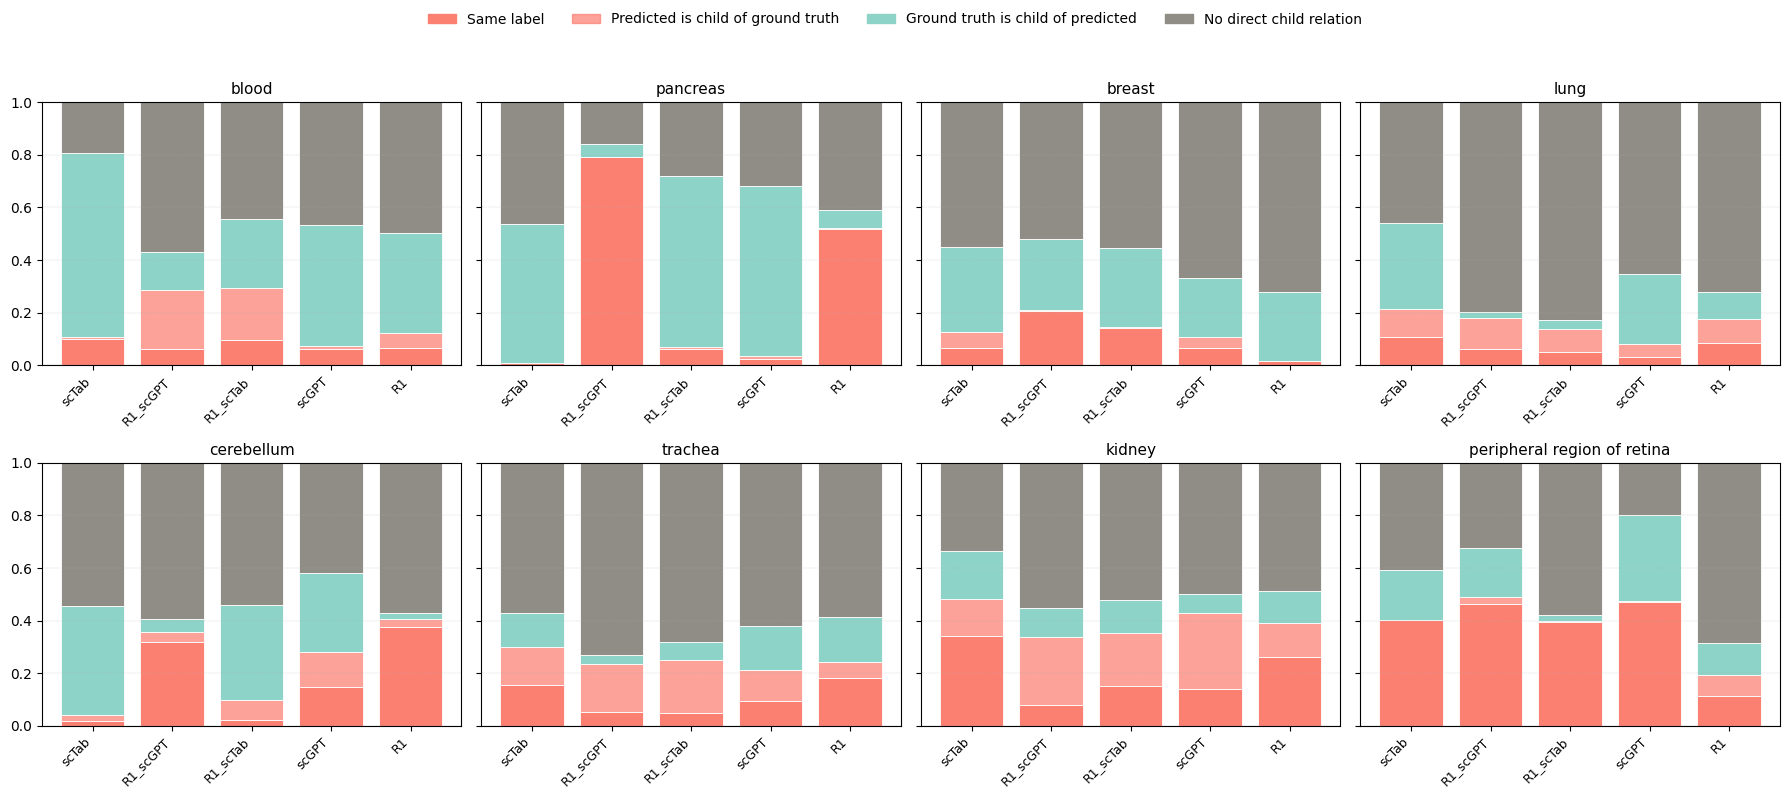

In [ ]:
# ------------------------------------------------------------
# prerequisites (already prepared in previous steps)
# ------------------------------------------------------------
# verdict_freqs : dict[str, np.ndarray]   # {tissue: 5×4 }
# prefixes      : list[str]               # ['scTab', 'R1_scGPT', 'R1_scTab', 'scGPT', 'R1']
# verdicts      : list[str]               # verdict 

# ------------------------------------------------------------
# plotting parameters
# ------------------------------------------------------------
n_rows, n_cols = 2, 4
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 8), sharey=True)
axes = axes.flatten()
colors         = ['#fb8072', "#fb8072ba", '#8dd3c7', 	"#908c86"]  # 4 colors

tissue_list = tissue_names

for ax, tissue in zip(axes, tissue_list):
    mat   = verdict_freqs[tissue]
    freqs = mat / mat.sum(axis=1, keepdims=True)

    bottom = np.zeros(len(prefixes))
    for v_lab, color in zip(verdicts, colors):
        ax.bar(
            x=np.arange(len(prefixes)),
            height=freqs[:, verdicts.index(v_lab)],
            bottom=bottom,
            color=color,
            edgecolor="white",
            linewidth=0.6,
        )
        bottom += freqs[:, verdicts.index(v_lab)]

    ax.set_xticks(range(len(prefixes)))
    ax.set_xticklabels(prefixes, rotation=45, ha="right", fontsize=9)
    ax.set_ylim(0, 1)
    ax.set_title(tissue, fontsize=11)
    ax.grid(axis="y", linestyle="--", linewidth=0.3, alpha=0.6)

# hide unused axes if any
for ax in axes[len(tissue_list):]:
    ax.set_visible(False)

# single legend
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in colors]
fig.legend(
    handles,
    ['Same label', 'Predicted is child of ground truth', 'Ground truth is child of predicted','No direct child relation'],
    loc="upper center",
    ncol=len(verdicts),
    frameon=False,
    fontsize=10,
)

fig.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()


In [22]:
present_blood = sheets['blood']
present_trachea = sheets['trachea']
present_lung = sheets['lung']
present_kidney = sheets['kidney']